<a href="https://colab.research.google.com/github/santoshs0612/Foundational-Math-in-ML/blob/main/RMSprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### RMS Propagation Gradient decent

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Loss Function definition(we starting with any random loss function)

In [ ]:
def quadratic_loss(x,y):
  return x**2 + 10 *y**2

### Gradient Function

In [ ]:
def quadratic_grad(x ,y):
  dx = 2 *x
  dy = 20* y
  return np.array([dx,dy])

### Batch Gradient decent

In [ ]:

def batch_grad_decent(grad_fun,eta, epochs,start_point):
  x ,y = start_point
  path = [(x,y)]
  losses = [quadratic_loss(x,y)]

  for _ in range(epochs):
    grad = grad_fun(x,y)
    x = x - eta * grad[0]
    y = y - eta * grad[1]
    path.append((x, y))
    losses.append(quadratic_loss(x,y))
  return np.array(path),losses

### RMS prop

In [ ]:
def rms_prop_optimizer(grad_fun,eta,beta,epochs,start_point):
  x ,y = start_point
  Eg2 = np.array([0.0,0.0]) # Moving Avg of Squared gradient
  path = [(x,y)]
  losses = [quadratic_loss(x,y)]
  for _ in range(epochs):
    grad = grad_fun(x,y)
    Eg2 = beta * Eg2 + (1-beta) * grad**2
    x = x - eta * grad[0] / (np.sqrt(Eg2[0] + 1e-8))
    y = y - eta * grad[1] / (np.sqrt(Eg2[1] + 1e-8))
    path.append((float(x), float(y)))
    losses.append(quadratic_loss(x,y))
  return np.array(path),losses



### Visualization of Paths

In [ ]:
def plot_paths(function,paths,labels,title):
  X,Y = np.meshgrid(np.linspace(-2,2,400),np.linspace(-2,2,400))
  Z = function(X,Y)
  plt.figure(figsize=(8,6))
  plt.contour(X,Y,Z,levels=50,cmap='jet')

  for path,label in zip(paths,labels):
    plt.plot(path[:,0],path[:,1],label=label)
    plt.scatter(path[0,0],path[0,1],color='green',label ="Start")
    plt.scatter(path[-1,0],path[-1,1],color='red',label ="End")
  plt.title(title)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.legend()
  plt.show()

### Visualization of losses

In [ ]:
def plot_losses(losses,labels,title):
  plt.figure(figsize=(8,6))
  for loss,label in zip(losses,labels):
    plt.plot(loss,label=label)
  plt.title(title)
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

### Parameter Defination

In [ ]:
eta_bgd = 0.1 #Learning rate for BGD
eta_rmsprop = 0.1 #Learning rate for momentum
beta = 0.9 #Momentum parameter
epochs = 100
start_point = (1.5, 1.5)


### Run Optimizations

In [ ]:
path_gd, losses_gd = batch_grad_decent(quadratic_grad, eta_bgd, epochs, start_point)
path_rmsprop, losses_rmsprop = rms_prop_optimizer(quadratic_grad, eta_rmsprop, beta, epochs, start_point)

### Plot Results

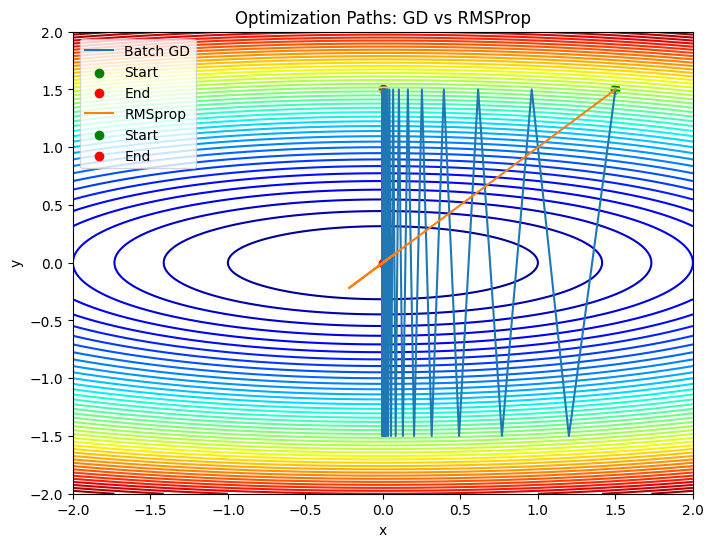

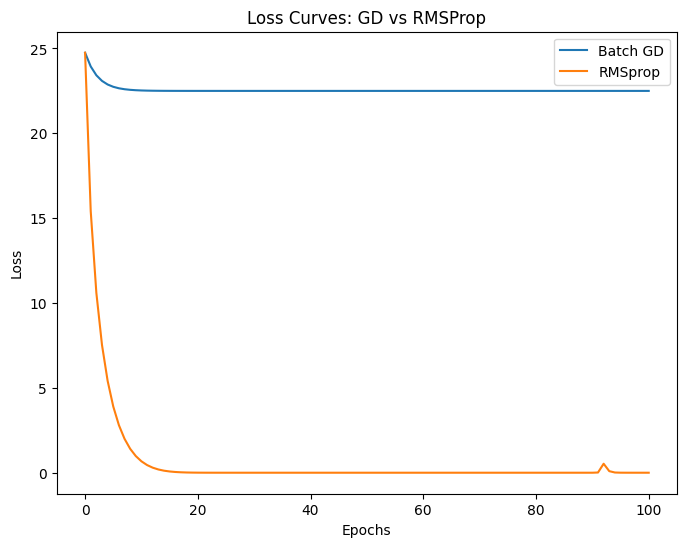

In [ ]:
plot_paths(quadratic_loss,[path_gd,path_rmsprop],['Batch GD','RMSprop'],"Optimization Paths: GD vs RMSProp")
plot_losses([losses_gd,losses_rmsprop],['Batch GD','RMSprop'],"Loss Curves: GD vs RMSProp")